# Sentiment Analysis Using Deep Learning Models

Colab notebook

The dataset is loaded ufrom imdb

Workflow:
- Dataset loading
- Sequence padding
- Review decoding
- TF-IDF + Logistic Regression baseline
- Embedding + Global Average Pooling neural model
- LSTM model
- Bidirectional LSTM controlled comparison
- Optional DistilBERT transformer section
- Evaluation metrics
- Results comparison
- Failure analysis
- Inference function
- Ethical considerations

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, LSTM, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# Parameters
vocab_size = 10000
maxlen = 300
embedding_size = 50
batch_size = 32
epochs = 5

label_names = ["Negative", "Positive"]

In [ ]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))
print("First encoded review sample:", x_train[0][:20])
print("First label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000
First encoded review sample: [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
First label: 1


In [ ]:
# Pad sequences to ensure uniform input size
x_train_pad = pad_sequences(x_train, maxlen=maxlen, padding="post", truncating="post")
x_test_pad = pad_sequences(x_test, maxlen=maxlen, padding="post", truncating="post")

print("Padded train shape:", x_train_pad.shape)
print("Padded test shape:", x_test_pad.shape)

Padded train shape: (25000, 300)
Padded test shape: (25000, 300)


In [ ]:
# Decode reviews back to readable text for baseline and failure analysis
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i - 3, "?") for i in encoded_review])

x_train_text = [decode_review(review) for review in x_train]
x_test_text = [decode_review(review) for review in x_test]

print(x_train_text[0][:1000])
print("Label:", label_names[y_train[0]])

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should

In [ ]:
# Create validation split for neural models
x_train_nn, x_val_nn, y_train_nn, y_val_nn = train_test_split(
    x_train_pad,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

# Create validation split for text baseline
x_train_text_base, x_val_text_base, y_train_base, y_val_base = train_test_split(
    x_train_text,
    y_train,
    test_size=0.2,
    random_state=SEED,
    stratify=y_train
)

print("Training shape:", x_train_nn.shape)
print("Validation shape:", x_val_nn.shape)

Training shape: (20000, 300)
Validation shape: (5000, 300)


In [ ]:
results = []

def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    print(f"\n===== {model_name} Results =====")
    print("Accuracy:", round(accuracy, 4))
    print(classification_report(y_true, y_pred, target_names=label_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()


===== TF-IDF + Logistic Regression Results =====
Accuracy: 0.8794
              precision    recall  f1-score   support

    Negative       0.88      0.87      0.88     12500
    Positive       0.87      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



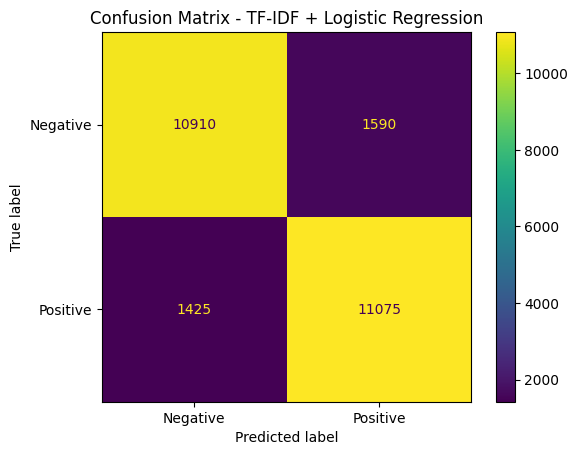

In [ ]:
# Baseline Model: TF-IDF + Logistic Regression
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(x_train_text_base)
X_test_tfidf = tfidf.transform(x_test_text)

baseline_model = LogisticRegression(max_iter=1000, random_state=SEED)
baseline_model.fit(X_train_tfidf, y_train_base)

y_pred_baseline = baseline_model.predict(X_test_tfidf)

evaluate_model("TF-IDF + Logistic Regression", y_test, y_pred_baseline)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7175 - loss: 0.5387 - val_accuracy: 0.8386 - val_loss: 0.3826
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8605 - loss: 0.3240 - val_accuracy: 0.8648 - val_loss: 0.3229
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8921 - loss: 0.2642 - val_accuracy: 0.8658 - val_loss: 0.3182
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9103 - loss: 0.2308 - val_accuracy: 0.8538 - val_loss: 0.3358
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9198 - loss: 0.2075 - val_accuracy: 0.8794 - val_loss: 0.3110
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

===== Embedding + Global Average Pooling Results =====
Accuracy: 0.8714
              precision    recall  f1-score   support

    Negative       0.87      0.87      0.87     12500
    Positive       0.87      0.87      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87 

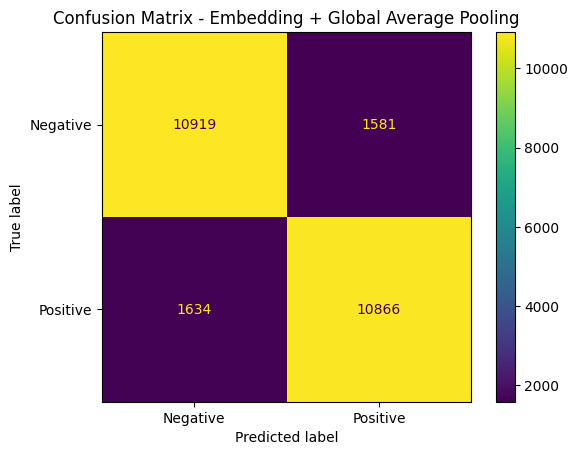

In [ ]:
# Model 1: Embedding + Global Average Pooling
avg_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_size, input_length=maxlen),
    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

avg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

avg_model.summary()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_avg = avg_model.fit(
    x_train_nn,
    y_train_nn,
    validation_data=(x_val_nn, y_val_nn),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

y_pred_avg = (avg_model.predict(x_test_pad) >= 0.5).astype(int).flatten()

evaluate_model("Embedding + Global Average Pooling", y_test, y_pred_avg)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 116s 180ms/step - accuracy: 0.5094 - loss: 0.6935 - val_accuracy: 0.5276 - val_loss: 0.6898
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 98s 158ms/step - accuracy: 0.5474 - loss: 0.6793 - val_accuracy: 0.5074 - val_loss: 0.7062
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step

===== LSTM Results =====
Accuracy: 0.5193
              precision    recall  f1-score   support

    Negative       0.51      0.90      0.65     12500
    Positive       0.58      0.14      0.23     12500

    accuracy                           0.52     25000
   macro avg       0.54      0.52      0.44     25000
weighted avg       0.54      0.52      0.44     25000



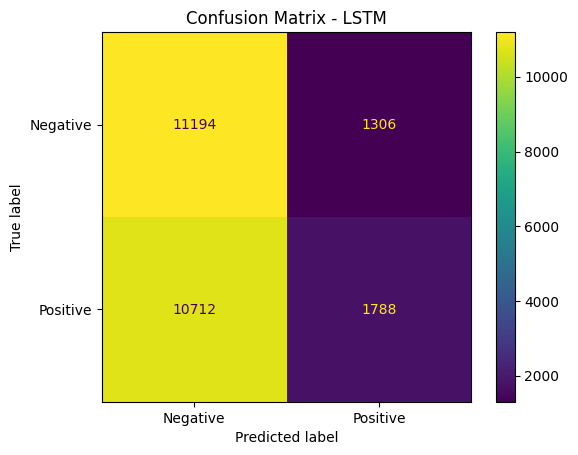

In [ ]:
# Model 2: LSTM
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_size, input_length=maxlen),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

history_lstm = lstm_model.fit(
    x_train_nn,
    y_train_nn,
    validation_data=(x_val_nn, y_val_nn),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

y_pred_lstm = (lstm_model.predict(x_test_pad) >= 0.5).astype(int).flatten()

evaluate_model("LSTM", y_test, y_pred_lstm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 189s 296ms/step - accuracy: 0.7623 - loss: 0.4928 - val_accuracy: 0.8426 - val_loss: 0.3847
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 294ms/step - accuracy: 0.8571 - loss: 0.3639 - val_accuracy: 0.8046 - val_loss: 0.4296
782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 71ms/step

===== Bidirectional LSTM Results =====
Accuracy: 0.831
              precision    recall  f1-score   support

    Negative       0.90      0.75      0.82     12500
    Positive       0.78      0.92      0.84     12500

    accuracy                           0.83     25000
   macro avg       0.84      0.83      0.83     25000
weighted avg       0.84      0.83      0.83     25000



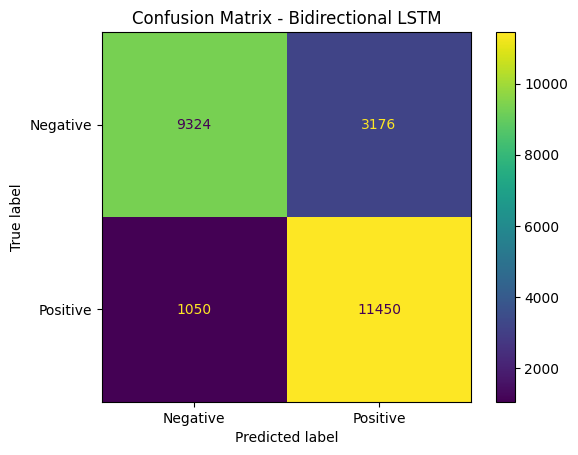

In [ ]:
# Model 3: Bidirectional LSTM - controlled comparison
bilstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_size, input_length=maxlen),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

bilstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

history_bilstm = bilstm_model.fit(
    x_train_nn,
    y_train_nn,
    validation_data=(x_val_nn, y_val_nn),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop],
    verbose=1
)

y_pred_bilstm = (bilstm_model.predict(x_test_pad) >= 0.5).astype(int).flatten()

evaluate_model("Bidirectional LSTM", y_test, y_pred_bilstm)